<a href="https://colab.research.google.com/github/mmj125/epistemic-demo/blob/main/Copy_of_Cycles_CONUS_using_Cycles_utils.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run Cycles given a defined field boundary

This notebook runs Cycles simulations using predscribed operations for a user-defined field.
The field can be defined using a `shp` shapefile or a `kml` file.
Soil files are generated from gSSURGO database, and weather files are generated from NLDAS.
**Note that you will need access to the Cycles global simulation database Google shared drive.**

## Instructions
**It is highly recommeded to save the notebook to your own drive, by using the "File -> Save a copy in Drive" option.**

To use this notebook for your areas of interest, change the block below.

- `BOUNDARY` is the path to your field boundary file.
  You can upload your `shp` or `kml` to the Colab session, in which case the path should start with `./`.
  You can also use an `shp` or `kml` file on your Google Drive, in which case the path should start with `/gdrive/`.
- `FIELD` is the name of the field, which is also the name of the simulation. Please do not use spaces in the field name.
- `START_YEAR` and `END_YEAR` are the simulation start and end years.
- `OPERATION` is the prescribed operation that is going to be simulated.
- `ROTATION_SIZE` is the number of years in the rotation.

After setting up the block below, you can run the notebook using the `Run all` command in the `Runtime` menu at the tool bar.
You can also run the blocks one by one by clicking the ▶️ buttons on the left of each block.

When asked to connect to your Google account, make sure to use the Google account with which you have access to the shared drive.

Any field in PA can be simulated.
The system can be readily expanded to the whole CONUS.

In [ ]:
BOUNDARY = "/gdrive/Shared drives/Cycles/RockSprings.kml" # @param {"type":"string","placeholder":"Path to the boundary "}
FIELD = "LTCorn" # @param {"type":"string","placeholder":"The name for the field. Please do not use spaces"}
START_YEAR = 2000 # @param {"type":"slider","min":1979,"max":2024,"step":1}
END_YEAR = 2024 # @param {"type":"slider","min":1979,"max":2024,"step":1}
OPERATION = "LTCorn" # @param {"type":"string","placeholder":"CornSoyWheatPasture"}
ROTATION_SIZE = 6 # @param {"type":"slider","min":1,"max":10,"step":1}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install and import packages

In [ ]:
!pip install cartopy &> /dev/null
!pip install fiona &> /dev/null
!pip install netCDF4 &> /dev/null
!pip install cycles-utils==2.0.0 &> /dev/null

In [ ]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import fiona
import geopandas as gpd
import math
import matplotlib
import matplotlib.colors as colors
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cycles.gadm as gadm
import cycles.weather as weather
from fiona.drvsupport import supported_drivers
from google.colab import drive
from cycles import read_operations, read_harvest
from cycles import generate_control_file, generate_soil_file
from cycles.gssurgo import Gssurgo
from cycles.plot import yield_plot, operation_plot

## Prepare model and data

### Define paths of required databases


In [ ]:
CYCLES_VERSION = '1.4.4'

# Path to gSSURGO data
GSSURGO_PATH = f'/gdrive/Shared drives/Cycles/gSSURGO/'

# Path to administrative region boundary data
GADM_PATH = '/gdrive/Shared drives/Cycles/gadm/'

# Path to NLDAS CONUS mask file and NLDAS weather file archive
NLDAS_ARCHIVE = '/gdrive/Shared\ drives/Cycles/Cycles\ global\ simulation\ database/weather/NLDAS_CONUS_1979-2024_3.6.7z'

drive.mount('/gdrive', force_remount=True)

<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1373677005.py:10: SyntaxWarning: invalid escape sequence '\ '
  NLDAS_ARCHIVE = '/gdrive/Shared\ drives/Cycles/Cycles\ global\ simulation\ database/weather/NLDAS_CONUS_1979-2024_3.6.7z'


Mounted at /gdrive


### Download Cycles from GitHub

In [ ]:
!wget -c https://github.com/PSUmodeling/Cycles/releases/download/v{CYCLES_VERSION}/Cycles_debian_{CYCLES_VERSION}.zip  &> /dev/nul
!unzip -jo Cycles_debian_{CYCLES_VERSION}.zip Cycles -d ./  &> /dev/nul
!unzip -jo Cycles_debian_{CYCLES_VERSION}.zip "input/*" -d ./input  &> /dev/nul

### Read field boundary
Read field boundary file and determine the location of the field

In [ ]:
def read_boundary(boundary: str) -> gpd.GeoDataFrame:
    format = boundary.split('.')[-1]
    match format:
        case 'shp':
            return gpd.read_file(boundary)
        case 'kml':
            # Empty GeoDataFrame
            gdf = gpd.GeoDataFrame()

            # Iterate over layers
            for layer in fiona.listlayers(boundary):
                s = gpd.read_file(boundary, driver='KML', layer=layer)
                gdf = pd.concat([gdf, s], ignore_index=True)

            return gpd.GeoDataFrame(gdf)
        case _:
            raise ValueError('Unsupported boundary format')


# Boundary
boundary = read_boundary(BOUNDARY)

# GADM
gadm_gdf = gadm.read_gadm(GADM_PATH, 'USA', 'state')
centroid = boundary.to_crs('+proj=cea').dissolve().centroid.to_crs(gadm_gdf.crs)
state = gpd.sjoin(gpd.GeoDataFrame({'geometry': centroid}), gadm_gdf, predicate='within', how='left')['HASC_1'][0].split('.')[1]
print(f'This field is located in {state}.')

This field is located in PA.


### Generate soil input

#### Find dominating soil type within the field boundary
Read gSSURGO data and aggregate the soil series by their map unit symbols (`musym`).
Then find the dominant soil type and extract soil physical parameters from gSSURGO.

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:2274: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  aggregated_data = data.groupby(**groupby_kwargs).agg(aggfunc, **kwargs)


Text(0.5, 0.98, 'Selected soil: Hagerstown silt loam (Ha), 538283')

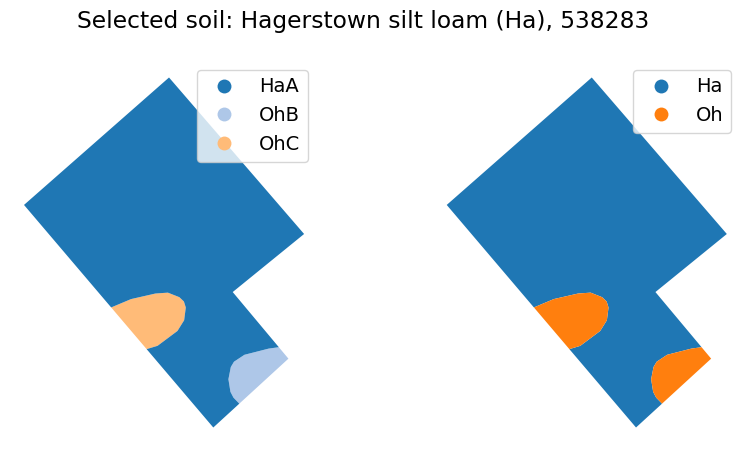

In [ ]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

gssurgo = Gssurgo(path=GSSURGO_PATH, state=state, boundary=boundary)
slope, hsg = gssurgo.average_slope_hsg()

gssurgo.mapunits.plot(
    ax=axes[0],
    column='musym',
    legend=True,
    cmap='tab20' if len(gssurgo.mapunits) > 20 else truncate_colormap(plt.get_cmap('tab20'), 0, len(gssurgo.mapunits) / 20),
)

gssurgo.group_map_units(geometry=True)

gssurgo.mapunits.plot(
    ax=axes[1],
    column='musym',
    legend=True,
    cmap='tab20' if len(gssurgo.mapunits) > 20 else truncate_colormap(plt.get_cmap('tab20'), 0, len(gssurgo.mapunits) / 20),
)

mukey, musym, muname = gssurgo.select_major_mapunit()

for ax in axes:
    ax.set_title('')
    ax.axis('off')
    ax.set_aspect('equal')

fig.suptitle(f'Selected soil: {muname} ({musym}), {mukey}')

#### Extract soil physical parameters to generate soil file
Extract hydrologic group, slope from the `muaggatt` look-up table.
Extract sand content, clay content, organic matter, and bulk density of each soil layer from the `chorizon` look-up table.
Nine soil layers with a total depths of 1.4 m is used, and is defined in a template soil file on Google Drive.

In [ ]:
soil_df = gssurgo.get_soil_profile_parameters(mukey=mukey)

generate_soil_file(f'./input/{FIELD}.soil', '', hsg, slope, soil_df)

### Get weather file
Weather files for CONUS generated from NLDAS-2 forcing are available in an archive on Google Drive. Calculate the NLDAS-2 grid in which the field is located, and extract the corresponding weather file from the archive.

In [ ]:
weather_file = list(weather.find_grids('NLDAS', [(centroid.y[0], centroid.x[0])])['weather_file'])[0]

NLDAS weather files:
                      input_coordinate                  weather_file
(40.71194485504497, -77.9515469035474) NLDAS_40.688Nx77.938W.weather



In [ ]:
!wget -c https://www.7-zip.org/a/7z2301-linux-x64.tar.xz &> /dev/null
!tar xvf ./7z2301-linux-x64.tar.xz 7zzs &> /dev/null

!./7zzs e {NLDAS_ARCHIVE} {weather_file} -y -o./input/


7-Zip (z) 23.01 (x64) : Copyright (c) 1999-2023 Igor Pavlov : 2023-06-20
 64-bit locale=en_US.UTF-8 Threads:2 OPEN_MAX:1048576, ASM

Scanning the drive for archives:
  0M Scan /gdrive/Shared drives/Cycles/Cycles global simulation database/weather/                                                                                 1 file, 10150297764 bytes (9681 MiB)

Extracting archive: /gdrive/Shared drives/Cycles/Cycles global simulation database/weather/NLDAS_CONUS_1979-2024_3.6.7z
--
Path = /gdrive/Shared drives/Cycles/Cycles global simulation database/weather/NLDAS_CONUS_1979-2024_3.6.7z
Type = 7z
Physical Size = 10150297764
Headers Size = 402088
Method = LZMA2:24
Solid = +
Blocks = 15

  0%      1%      2%      3%      4%      5%      6%      7%      8%    

## Run Cycles
Define start year and end year of simulation, and the rotation to run the Cycles simulation.
The soil and weather files generated above will be used.

In [ ]:
control_data = {
    'simulation_start_date': f'{START_YEAR:04}',
    'simulation_end_date': f'{END_YEAR:04}',
    'rotation_size': ROTATION_SIZE,
    'operation_file': f'{OPERATION}.operation',
    'soil_file': f'{FIELD}.soil',
    'weather_file': weather_file,
}

generate_control_file(f'./input/{FIELD}.ctrl', control_data)

!./Cycles -s {FIELD}



               ########                      
           ################                  
         ####################                
        ######           ######        ######
       ######          ##########     ###### 
      ######            ########     ######  
      #####               #####     ######   
      #####                 #      ######    
      ######                ##### ######     
       ######            ##############      
        #######        ###### ########       
         ####################  ######        
            ##############     #####         
                ######        #####          
                         #########           
                         ########            

                   Version 1.4.4


Simulation LTCorn running ...

Read soil initialization file: input/LTCorn.soil.
Read crop description file:    input/GenericCrops.crop.
Read field operation file:     input/LTCorn.operation.

Error: input file format error in

## Plot

In [ ]:
fig = plt.figure(layout='constrained', figsize=(16, 12))
subfigs = fig.subfigures(2, 1, wspace=0.07)

df = read_operations('./', OPERATION)

axes = subfigs[0].subplots(ROTATION_SIZE, 1, sharex=True)
if ROTATION_SIZE == 1: axes = [axes]

operation_plot(df, ROTATION_SIZE, axes=axes, fontsize=12)

url = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}.jpg'
request = cimgt.GoogleTiles(url=url)

ax = subfigs[1].add_axes([0.05, 0.05, 0.25, 0.9], projection=request.crs)
xmin, ymin, xmax, ymax = boundary.to_crs(ccrs.PlateCarree()).total_bounds

xmin = (xmin - centroid.x[0]) * 1.5 + centroid.x[0]
ymin = (ymin - centroid.y[0]) * 1.5 + centroid.y[0]
xmax = (xmax - centroid.x[0]) * 1.5 + centroid.x[0]
ymax = (ymax - centroid.y[0]) * 1.5 + centroid.y[0]

extent = [xmin, xmax, ymin, ymax]

def zoom_from_extent(extent):
    dx = extent[1] - extent[0]
    dy = extent[3] - extent[2]
    y0 = 0.5 * (extent[2] + extent[3])

    return int(4 - 1 / math.log(2) * math.log(min(dx * math.cos(math.pi / 180 * y0), dy) / 180))

ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_image(request, zoom_from_extent(extent))

boundary.to_crs(request.crs).boundary.plot(ax=ax)

df = read_harvest('./', FIELD)
ax = subfigs[1].add_axes([0.38, 0.05, 0.6, 0.9])
yield_plot(df, ax=ax, fontsize=14)

IndexError: list index out of range

<Figure size 1600x1200 with 0 Axes>